<a href="https://colab.research.google.com/github/AndreaMagri/tesi-ardl-hicp/blob/main/tesi_uecm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi Empirica del Pass-Through degli Shock Logistici sull'Inflazione Europea
**Autore**: Andrea Magri  
**Corso di Laurea**: Triennale in Economia e Finanza  
**Università**: Alma Mater Studiorum - Università di Bologna  

Questo notebook rappresenta l'ambiente di calcolo ufficiale per la replica dei risultati presentati nella tesi di laurea.  
L'analisi si propone di misurare l'effetto di breve e di lungo periodo degli shock della supply chain globale (catturati dall'indice *Global Supply Chain Pressure Index* - GSCPI) sui prezzi al consumo dell'Eurozona (indice HICP destagionalizzato) nel periodo 1999-2026.  

Sotto il profilo metodologico, si adotta un modello **Autoregressivo a Ritardi Distribuiti (ARDL)** espresso nella forma di **correzione dell'errore non vincolata (UECM)**, controllando al contempo per i costi energetici (petrolio Brent), per il tasso di cambio nominale (EUR/USD) e per l'orientamento della politica monetaria (Euribor 3 mesi).

In [116]:
import io
import random
import datetime
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import norm

# Importazioni per analisi di serie storiche
import statsmodels.api as sm
from statsmodels.tsa.api import ARDL
from statsmodels.tsa.ardl import UECM, ardl_select_order
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA

# Diagnostica sui residui e test statistici
from statsmodels.stats.diagnostic import het_arch, acorr_lm, breaks_cusumolsresid
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Librerie di visualizzazione interattiva
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Verifica e installazione silente di pandas_datareader per importare dati da FRED
try:
    import  pandas_datareader.data as web
except ImportError:
    import sys
    !{sys.executable} -m pip install pandas_datareader -q
    import pandas_datareader.data as web
else:
    import pandas_datareader.data as web

# Verifica e installazione silente di pmdarima per la selezione automatica degli ARIMA
try:
    import pmdarima
except ImportError:
    import sys
    !{sys.executable} -m pip install pmdarima -q
    from pmdarima.arima import auto_arima
else:
    from pmdarima.arima import auto_arima

# Configurazione di riproducibilità e stile grafico
seed = 42
random.seed(seed)
np.random.seed(seed)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

# FLAG GLOBALE PER ESPORTAZIONE GRAFICI
# Imposta su True solo se desideri scaricare le immagini .png ad alta risoluzione (300 DPI)
SAVE_IMAGES = False

## 1. Caricamento e Preparazione dei Dati (Livelli)
In questa sezione vengono scaricati i dati macroeconomici da FRED e dal portale dati della BCE (ECB API).  
L'indice HICP viene importato nella sua forma destagionalizzata (SA). L'indice GSCPI viene caricato dal file CSV (dati fino a Giugno 2026) ospitato su Github poiché, per ogni nuovo dato aggiunto il GSCPI viene rinormalizzato.

In [117]:
start_date = datetime.datetime(1998, 1, 1)
end_date = datetime.datetime(2026, 7, 1)

fred_codes = {
    'EUR_USD_Exchange': 'DEXUSEU',
    'Oil': 'POILBREUSDM'
}

# EUR/USD e Petrolio da FRED
print("Scaricamento dati da FRED...")
df_fred = web.DataReader(list(fred_codes.values()), "fred", start_date, end_date)
df_fred.columns = fred_codes.keys()
df_macro = df_fred.resample("ME").mean().ffill()

# Caricamento GSCPI (Assicurati del percorso su Drive)
gscpi_path = "https://raw.githubusercontent.com/AndreaMagri/tesi-ardl-hicp/201f23afb5a523225185f779ee00848bfcf4f517/gscpi_data_all.csv"
print(f"Caricamento GSCPI da Github")
gscpi_series = pd.read_csv(gscpi_path, parse_dates=True, index_col=0)
gscpi_series.columns = ["gscpi"]
gscpi_series["DATE"] = pd.to_datetime(gscpi_series.index) + pd.offsets.MonthEnd(0)
gscpi_series.set_index("DATE", inplace=True)

# Scaricamento HICP da ECB API
print("Scaricamento HICP da ECB API...")
url_hicp = (
    "https://data-api.ecb.europa.eu/service/data/HICP/M.U2.Y.000000.4F0.INX?format=csvdata&detail=dataonly"
    + "&startPeriod=" + start_date.strftime("%Y-%m-%d")
    + "&endPeriod=" + end_date.strftime("%Y-%m-%d")
)
response = requests.get(url_hicp)
df_hicp_ = pd.read_csv(io.StringIO(response.text))
hicp_series = df_hicp_[["TIME_PERIOD", "OBS_VALUE"]].copy()
hicp_series.columns = ["DATE", "hicp"]
hicp_series["DATE"] = pd.to_datetime(hicp_series["DATE"]) + pd.offsets.MonthEnd(0)
hicp_series.set_index("DATE", inplace=True)

# Scaricamento Euribor da ECB API
print("Scaricamento Euribor da ECB API...")
url_euribor = (
    "https://data-api.ecb.europa.eu/service/data/FM/M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA?format=csvdata&detail=dataonly"
    + "&startPeriod=" + start_date.strftime("%Y-%m-%d")
    + "&endPeriod=" + end_date.strftime("%Y-%m-%d")
)
response = requests.get(url_euribor)
df_euribor_ = pd.read_csv(io.StringIO(response.text))
euribor_series = df_euribor_[["TIME_PERIOD", "OBS_VALUE"]].copy()
euribor_series.columns = ["DATE", "euribor"]
euribor_series["DATE"] = pd.to_datetime(euribor_series["DATE"]) + pd.offsets.MonthEnd(0)
euribor_series.set_index("DATE", inplace=True)

# Merge & Trasformazioni Logaritmiche
df_extended = df_macro.join(gscpi_series, how="inner").join(hicp_series, how="inner").join(euribor_series, how="inner").dropna()
df_extended["l_hicp"] = np.log(df_extended["hicp"])
df_extended["l_oil"] = np.log(df_extended["Oil"])
df_extended["l_fx"] = np.log(df_extended["EUR_USD_Exchange"])

# Dataset finale per la stima (330 osservazioni)
df = df_extended[['l_hicp', 'gscpi', 'l_oil', 'l_fx', 'euribor']].asfreq('ME')
df_diff = df.diff().dropna() # Calcoliamo anche il dataset in differenze per i grafici temporali

# Dummy COVID-19 (Regime Shift da Gennaio 2021)
covid_dummy = pd.DataFrame(
    (df.index >= '2021-01-01').astype(int),
    index=df.index,
    columns=['covid_dummy']
)
print(f"Dataset preparato con successo. Numero osservazioni: {len(df)}")

Scaricamento dati da FRED...
Caricamento GSCPI da Github
Scaricamento HICP da ECB API...
Scaricamento Euribor da ECB API...
Dataset preparato con successo. Numero osservazioni: 330


## 2. Analisi Esplorativa dei Dati (EDA)
In questa sezione visualizziamo graficamente la presenza di dati mancanti e confrontiamo le variabili nei loro livelli originari rispetto alle trasformazioni logaritmiche. Viene inoltre compilata la tavola delle statistiche descrittive (Tabella 4.1 della tesi) per analizzare la asimmetria e l'elevata curtosi (fat tails) dei dati in differenze prime.

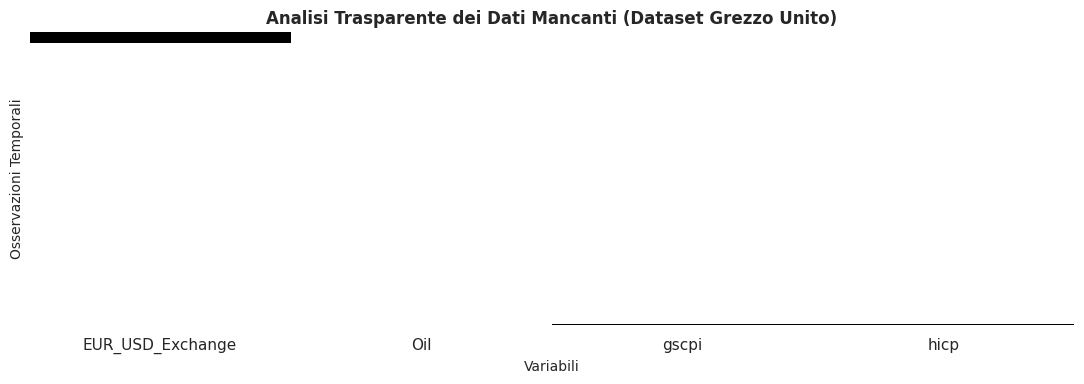

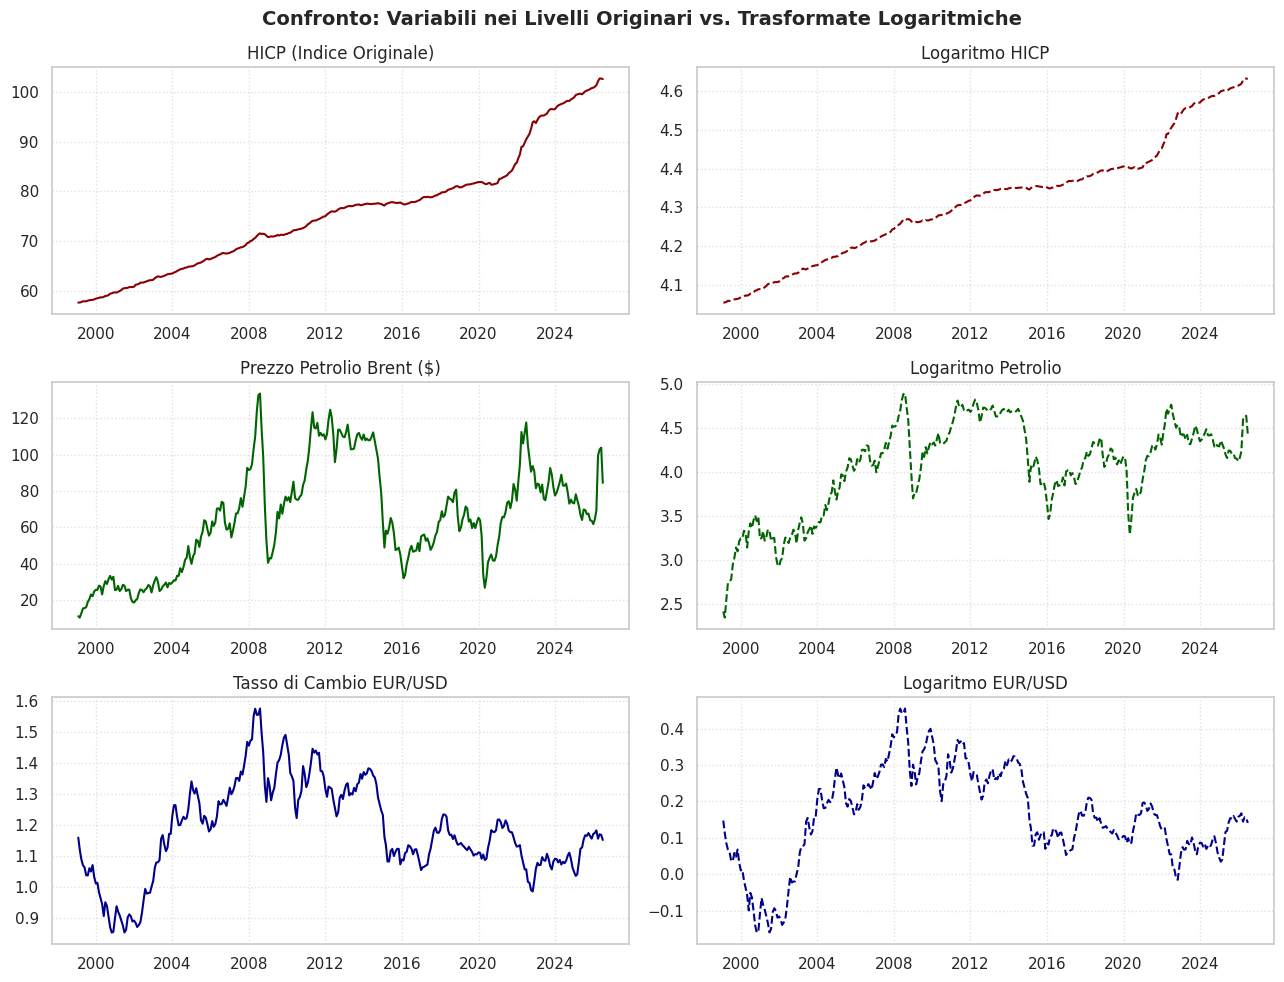


                      TABELLA DELLE STATISTICHE DESCRITTIVE
           count    mean     std     min     max  skewness  kurtosis
l_hicp     330.0  4.3171  0.1526  4.0556  4.6313    0.2341   -0.6469
gscpi      330.0  0.0308  1.0118 -1.5753  4.4369    1.9673    4.4166
l_oil      330.0  4.0648  0.5212  2.3446  4.8947   -0.7334   -0.0793
l_fx       330.0  0.1590  0.1298 -0.1595  0.4548   -0.2373   -0.1560
euribor    330.0  1.6843  1.7445 -0.5820  5.1131    0.2813   -1.2328
D.l_hicp   329.0  0.0017  0.0024 -0.0044  0.0179    1.8850    9.3339
D.gscpi    329.0  0.0047  0.3835 -1.4826  1.3746   -0.1579    1.3328
D.l_oil    329.0  0.0061  0.0931 -0.4950  0.3592   -0.8691    3.4748
D.l_fx     329.0 -0.0000  0.0216 -0.0779  0.0619   -0.0040    0.5712
D.euribor  329.0 -0.0024  0.1497 -0.9457  0.6490   -1.3980   12.7308


In [118]:
# A. Heatmap dei dati mancanti nel dataset grezzo unito
df_raw_merged = df_macro.join(gscpi_series, how="outer").join(hicp_series, how="outer")
plt.figure(figsize=(11, 4))
sns.heatmap(df_raw_merged.isnull(), cbar=False, yticklabels=False, cmap="binary")
plt.title("Analisi Trasparente dei Dati Mancanti (Dataset Grezzo Unito)", fontsize=12, fontweight="bold")
plt.xlabel("Variabili", fontsize=10)
plt.ylabel("Osservazioni Temporali", fontsize=10)
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig("dati_mancanti.png", dpi=300)
plt.show()

# B. Confronto livelli originari vs. trasformazioni logaritmiche
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
fig.suptitle("Confronto: Variabili nei Livelli Originari vs. Trasformate Logaritmiche", fontsize=14, fontweight="bold")

axes[0, 0].plot(df_extended.index, df_extended['hicp'], color="darkred", lw=1.5)
axes[0, 0].set_title("HICP (Indice Originale)")
axes[0, 1].plot(df_extended.index, df_extended['l_hicp'], color="darkred", lw=1.5, linestyle="--")
axes[0, 1].set_title("Logaritmo HICP")

axes[1, 0].plot(df_extended.index, df_extended['Oil'], color="darkgreen", lw=1.5)
axes[1, 0].set_title("Prezzo Petrolio Brent ($)")
axes[1, 1].plot(df_extended.index, df_extended['l_oil'], color="darkgreen", lw=1.5, linestyle="--")
axes[1, 1].set_title("Logaritmo Petrolio")

axes[2, 0].plot(df_extended.index, df_extended['EUR_USD_Exchange'], color="darkblue", lw=1.5)
axes[2, 0].set_title("Tasso di Cambio EUR/USD")
axes[2, 1].plot(df_extended.index, df_extended['l_fx'], color="darkblue", lw=1.5, linestyle="--")
axes[2, 1].set_title("Logaritmo EUR/USD")

for ax in axes.flat:
    ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig("levels_vs_logs.png", dpi=300)
plt.show()

# C. Calcolo delle Statistiche Descrittive (Livelli e Differenze)
def descriptive_statistics_table(df_data):
    levels = df_data[['l_hicp', 'gscpi', 'l_oil', 'l_fx', 'euribor']]
    diffs = levels.diff().dropna()
    diffs.columns = [f"D.{c}" for c in diffs.columns]

    desc_lvl = levels.describe().T[['count', 'mean', 'std', 'min', 'max']]
    desc_lvl['skewness'] = levels.skew()
    desc_lvl['kurtosis'] = levels.kurtosis()

    desc_df = diffs.describe().T[['count', 'mean', 'std', 'min', 'max']]
    desc_df['skewness'] = diffs.skew()
    desc_df['kurtosis'] = diffs.kurtosis()

    final_table = pd.concat([desc_lvl, desc_df])
    print("\n" + "="*80 + "\n                      TABELLA DELLE STATISTICHE DESCRITTIVE\n" + "="*80)
    print(final_table.round(4).to_string())
    return final_table

desc_stats = descriptive_statistics_table(df)

### Visualizzazioni Interattive
In questa cella definiamo una funzione universale per la traduzione dei grafici storici della tesi in formato interattivo. Questa funzione permette all'utente online di scorrere la serie temporale, visualizzare i tooltip dinamici delle aree ombreggiate.

In [119]:
# Mappatura degli eventi sulla Supply Chain e Crisi Globali
events_gscpi = [
    {"start": "1999-01-01", "end": "1999-12-31", "label": "Crisi Asiatiche", "color": "green", "type": "span"},
    {"start": "2003-03-01", "end": "2003-07-01", "label": "Epidemia SARS", "color": "#e67e22", "type": "span"},
    {"start": "2008-09-01", "end": "2009-03-01", "label": "GFC (Crollo domanda/noli)", "color": "#d32f2f", "type": "span"},
    {"start": "2011-03-11", "end": "2011-06-30", "label": "Tsunami Tohoku (Chip/Auto)", "color": "#7b1fa2", "type": "span"},
    {"start": "2020-03-01", "end": "2022-12-31", "label": "Pandemia COVID & Zero-COVID", "color": "#c2185b", "type": "span"},
    {"start": "2021-03-23", "end": "2021-03-29", "label": "Ever Given (Suez)", "color": "#0097a7", "type": "line"},
    {"start": "2023-12-01", "end": "2026-06-01", "label": "Crisi Medio Oriente Houthi/Hormuz", "color": "#e64a19", "type": "span"}
]

# Mappatura dei regimi di Politica Monetaria della BCE
events_euribor = [
    {"start": "1999-01-01", "end": "2007-12-31", "label": "Gestione Convenzionale", "color": "#34495e", "type": "span"},
    {"start": "2008-10-01", "end": "2009-05-01", "label": "Tagli d'Emergenza GFC", "color": "#e74c3c", "type": "span"},
    {"start": "2011-07-01", "end": "2011-11-01", "label": "Errore di Trichet", "color": "#e67e22", "type": "span"},
    {"start": "2012-07-26", "end": "2012-07-26", "label": '"Whatever It Takes" (Draghi)', "color": "#2980b9", "type": "line"},
    {"start": "2014-06-01", "end": "2022-07-01", "label": "Tassi Negativi & QE (APP/PEPP)", "color": "#f1c40f", "type": "span"},
    {"start": "2022-07-01", "end": "2023-09-01", "label": "Stretta Monetaria (+450 bps)", "color": "#8e44ad", "type": "span"},
    {"start": "2024-06-01", "end": "2026-06-01", "label": "Fase di Allentamento (Cut Cycle)", "color": "#2ecc71", "type": "span"}
]

# Mappatura dei periodi e delle dinamiche del cambio EUR/USD
events_EUR_USD_Exchange = [
    {"start": "2000-01-01", "end": "2000-10-31", "label": "Svalutazione Euro", "color": "#e74c3c"},
    {"start": "2002-01-01", "end": "2008-07-31", "label": "Apprezzamento Record (Picco ~$1,60)", "color": "#2ecc71"},
    {"start": "2010-01-01", "end": "2012-12-31", "label": "Volatilità Crisi Debito Sovrano", "color": "#e67e22"},
    {"start": "2014-01-01", "end": "2015-12-31", "label": "Divergenza QE BCE vs Fed", "color": "#9b59b6"},
    {"start": "2022-07-01", "end": "2022-09-30", "label": "Rottura Parità (< 1,00 USD)", "color": "#c0392b"},
    {"start": "2023-01-01", "end": "2026-06-30", "label": "Stabilizzazione", "color": "#3498db"}
]

# Mappatura dei periodi e delle dinamiche del mercato del petrolio
events_Oil = [
    {"start": "1999-01-01", "end": "2008-07-01", "label": "Super-ciclo Commodities", "color": "#27ae60"},
    {"start": "2008-08-01", "end": "2008-12-01", "label": "Crollo Crisi Finanziaria", "color": "#c0392b"},
    {"start": "2011-01-01", "end": "2014-06-01", "label": "Primavera Araba (> $100/b)", "color": "#f39c12"},
    {"start": "2014-06-01", "end": "2016-02-01", "label": "Guerra quote OPEC vs US Shale", "color": "#8e44ad"},
    {"start": "2020-03-01", "end": "2020-04-30", "label": "Shock COVID / Prezzi Negativi WTI", "color": "#d35400"},
    {"start": "2022-02-01", "end": "2022-06-30", "label": "Invasione Ucraina (Shock Forniture)", "color": "blue"},
    {"start": "2023-01-01", "end": "2026-06-01", "label": "Riequilibrio & Tensioni M.O.", "color": "#2980b9"}
]

# Mappatura dei periodi e delle dinamiche dell'inflazione
events_hicp = [
    {"start": "1999-01-01", "end": "1999-12-31", "label": "Fase Pre-Euro e Bassa Inflazione", "color": "green"},
    {"start": "2000-01-01", "end": "2008-07-01", "label": "Stabilità ed Espansione", "color": "green"},
    {"start": "2009-07-01", "end": "2009-10-01", "label": "Deflazione GFC", "color": "red"},
    {"start": "2010-01-01", "end": "2012-12-31", "label": "Crisi Debito Sovrano", "color": "#e67e22"},
    {"start": "2014-01-01", "end": "2016-12-01", "label": "Bassa Inflazione / Rischio Deflazione", "color": "orange"},
    {"start": "2020-03-01", "end": "2021-01-01", "label": "Shock COVID-19", "color": "purple"},
    {"start": "2021-06-01", "end": "2022-10-01", "label": "Shock Energetico", "color": "crimson"},
    {"start": "2023-01-01", "end": "2026-06-01", "label": "Rientro / Normalizzazione", "color": "blue"},
]


# Definizione della funzione universale Plotly per i grafici storici della tesi
def plot_interactive_macro_events(df_data, column_name, events_list, title, y_label, is_percentage=False):
    fig = go.Figure()

    # Tracciamento della linea principale
    fig.add_trace(
        go.Scatter(
            x=df_data.index, y=df_data[column_name], mode='lines',
            line=dict(color='#2c3e50', width=2.2), name=y_label,
            hovertemplate="<b>Data</b>: %{x|%B %Y}<br><b>Valore</b>: %{y:.4f}<extra></extra>"
        )
    )

    # Linee di riferimento
    if column_name == 'euribor':
        fig.add_hline(y=0, line_width=1, line_dash="dash", line_color="gray")
    elif column_name == 'Oil':
        fig.add_hline(y=100, line_width=1, line_dash="dash", line_color="gray")
    elif column_name == 'EUR_USD_Exchange':
        fig.add_hline(y=1.00, line_width=1.2, line_dash="dash", line_color="#d32f2f")
        fig.add_hline(y=1.20, line_width=1.0, line_dash="dot", line_color="gray")
    elif column_name == 'gscpi':
        fig.add_hline(y=0, line_width=1, line_dash="dash", line_color="gray")

    for idx, ev in enumerate(events_list):
        start_dt = pd.to_datetime(ev["start"])
        end_dt = pd.to_datetime(ev["end"])
        ev_type = ev.get("type", "span")

        if ev_type == "span" and start_dt != end_dt:
            fig.add_vrect(
                x0=start_dt, x1=end_dt, fillcolor=ev["color"], opacity=0.12,
                layer="below", line_width=0, annotation_text=f" {ev['label']}",
                annotation_position="top left",
                annotation_font=dict(size=8, color=ev["color"], family="Arial")
            )
        else: # ev_type == "line"
            # Add the vertical line without annotation parameters
            fig.add_vline(
                x=start_dt.to_pydatetime(),
                line_width=1.5, line_dash="dashdot", line_color=ev["color"]
            )
            # Add the annotation separately
            fig.add_annotation(
                x=start_dt.to_pydatetime(), # Use the datetime for annotation x
                yref="paper", y=0.9, # Position annotation at 90% of y-axis height (paper coordinates)
                text=f"  {ev['label']}",
                textangle=-90,
                showarrow=False,
                xanchor="left", # Anchor text to the left of the x-coordinate
                font=dict(size=8, color=ev["color"], family="Arial"),
                bgcolor="rgba(255, 255, 255, 0.7)" # Add a slight background for readability
            )

    fig.update_layout(
        title=dict(text=title, font=dict(size=14, family="Arial", color="black")),
        xaxis=dict(title="Data", showgrid=True, gridcolor='whitesmoke', range=[df_data.index.min(), df_data.index.max()]),
        yaxis=dict(title=y_label, showgrid=True, gridcolor='whitesmoke', tickformat=".2f%" if is_percentage else None),
        template="plotly_white", hovermode="x unified", height=500, width=1100, showlegend=False
    )
    fig.show()

# Grafico interattivo per il GSCPI
plot_interactive_macro_events(
    df_data=df_extended, column_name="gscpi", events_list=events_gscpi,
    title="Evoluzione Interattiva dell'Indice GSCPI (1999-2026)", y_label="Indice GSCPI"
)
# Grafico interattivo per il Petrolio
plot_interactive_macro_events(
    df_data=df_extended, column_name="Oil", events_list=events_Oil,
    title="Evoluzione Interattiva dell'Prezzo Brent (1999-2026)", y_label="USD/Barile"
)

# Grafico interattivo per Euribor
plot_interactive_macro_events(
    df_data=df, column_name="euribor", events_list=events_euribor,
    title="Evoluzione Interattiva del Tasso Euribor a 3 Mesi(1999-2026)", y_label="Tasso Euribor (%)"
)

# Grafico interattivo per Cambio
plot_interactive_macro_events(
    df_data=df_extended, column_name="EUR_USD_Exchange", events_list=events_EUR_USD_Exchange,
    title="Evoluzione Interattiva del Tasso di Cambio Nominale(1999-2026)", y_label="USD per 1 Euro"
)

### Grafico Interattivo HICP
Questa cella genera una visualizzazione interattiva a due pannelli sovrapposti per l'HICP (Indice in livello sopra, Tasso mensile sotto) con le aree di regime ombreggiate e l'hover temporale collegato in automatico tra i due grafici.

In [120]:
# Creazione della griglia a 2 righe e 1 colonna con altezza condivisa
fig_hicp = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=("Indice HICP Eurozona (Livello)", "Tasso HICP Eurozona (Variazione Mensile %)")
)

# 1. Pannello Superiore (Livelli)
fig_hicp.add_trace(
    go.Scatter(
        x=df_extended.index, y=df_extended["hicp"], mode='lines',
        line=dict(color='#1f77b4', width=2.2), name="Indice HICP",
        hovertemplate="Data: %{x|%B %Y}<br>Indice: %{y:.4f}<extra></extra>"
    ),
    row=1, col=1
)

# 2. Pannello Inferiore (Differenze Prime / Tasso Mensile)
fig_hicp.add_trace(
    go.Scatter(
        x=df_diff.index, y=df_diff["l_hicp"] * 100, mode='lines',
        line=dict(color='#2c3e50', width=2), name="Tasso HICP",
        hovertemplate="Data: %{x|%B %Y}<br>Tasso Mensile: %{y:.4f}%<extra></extra>"
    ),
    row=2, col=1
)

# Riga dello zero sul pannello inferiore
fig_hicp.add_hline(y=0, line_width=1, line_dash="dash", line_color="gray", row=2, col=1)

# Estrazione dinamica del minimo e del massimo reali dell'indice HICP
y_min_hicp = df_extended["hicp"].min()
y_max_hicp = df_extended["hicp"].max()

# 3. Applicazione delle aree ombreggiate di regime su entrambi i pannelli
for idx, ev in enumerate(events_hicp):
    start_dt = pd.to_datetime(ev["start"])
    end_dt = pd.to_datetime(ev["end"])

    # Applichiamo la fascia verticale a entrambi i subplot (row=1 e row=2)
    for r in [1, 2]:
        fig_hicp.add_vrect(
            x0=start_dt, x1=end_dt,
            fillcolor=ev["color"], opacity=0.10,
            layer="below", line_width=0,
            row=r, col=1
        )

    # Calcolo posizione Y alternata agganciata ai REALI dati HICP del primo pannello
    mid_dt = start_dt + (end_dt - start_dt) / 2
    y_pos = y_max_hicp - (0.05 + (idx % 2) * 0.12) * (y_max_hicp - y_min_hicp)

    # Inseriamo l'annotazione legandola alla reale coordinata Y del primo grafico (row=1, col=1)
    fig_hicp.add_annotation(
        x=mid_dt,
        y=y_pos, # Utilizza i dati reali dell'indice
        text=ev["label"],
        showarrow=False,
        textangle=-90,
        font=dict(size=8, color=ev["color"], family="Arial", weight="bold"),
        bgcolor="rgba(255, 255, 255, 0.75)",
        row=1, col=1
    )

# Configurazione del layout finale
fig_hicp.update_layout(
    title=dict(text="Analisi Storica dei Regimi dell'Inflazione Europea (HICP)", font=dict(size=14, family="Arial")),
    template="plotly_white",
    hovermode="x unified",
    height=750,
    width=1100,
    showlegend=False
)

# Formattazione degli assi con i limiti reali dell'HICP (impedisce la scala negativa)
fig_hicp.update_xaxes(range=[df_extended.index.min(), df_extended.index.max()], row=2, col=1)
# Forziamo l'asse Y a muoversi in modo pulito intorno ai valori dell'indice (es. da 55 a 120)
fig_hicp.update_yaxes(title_text="Indice HICP", range=[y_min_hicp - 5, y_max_hicp + 15], row=1, col=1)
fig_hicp.update_yaxes(title_text="Tasso Mensile (%)", tickformat=".2f%", row=2, col=1)

fig_hicp.show()

## 3. Proprietà delle Serie Storiche e Diagnostiche di Base
In questa sezione verifichiamo l'ordine di integrazione delle serie storiche tramite i test formali di Dickey-Fuller Aumentato (ADF) e KPSS.  
Viene inoltre verificata l'indice di correlazione, generati i correlogrammi ACF/PACF in una griglia pulita, calcolato il VIF per escludere la multicollinearità delle determinanti di lungo periodo, ed eseguita la selezione ottimale del modello ARIMA per l'indice GSCPI (comprovandone la natura stazionaria ma ad altissima persistenza).

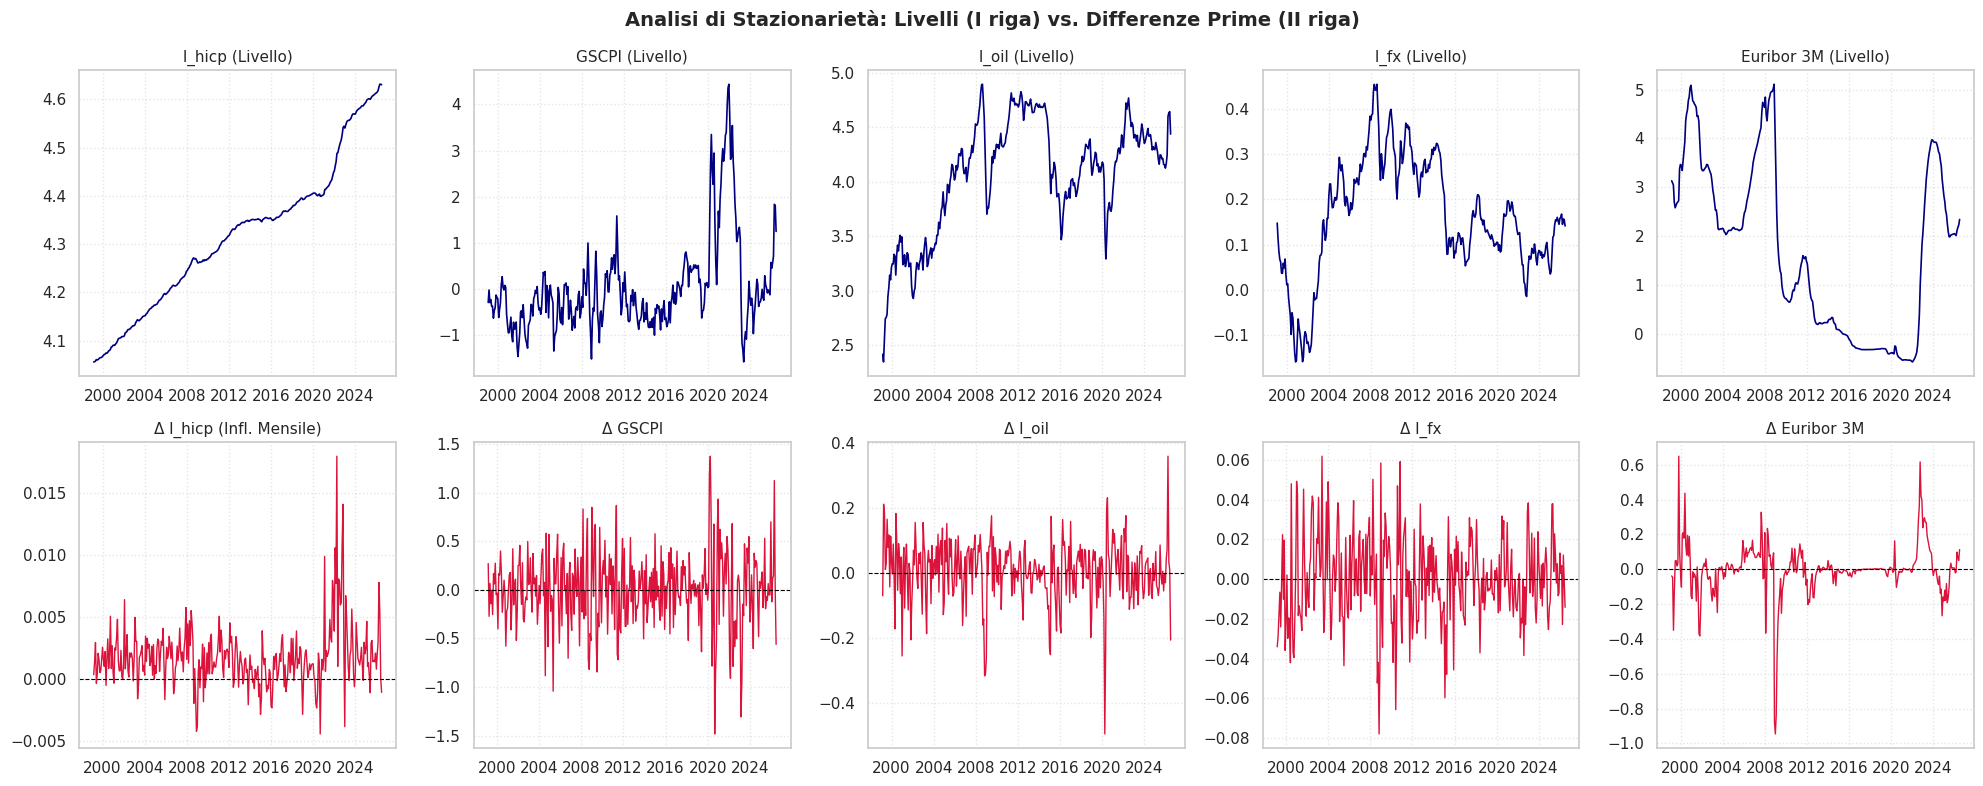

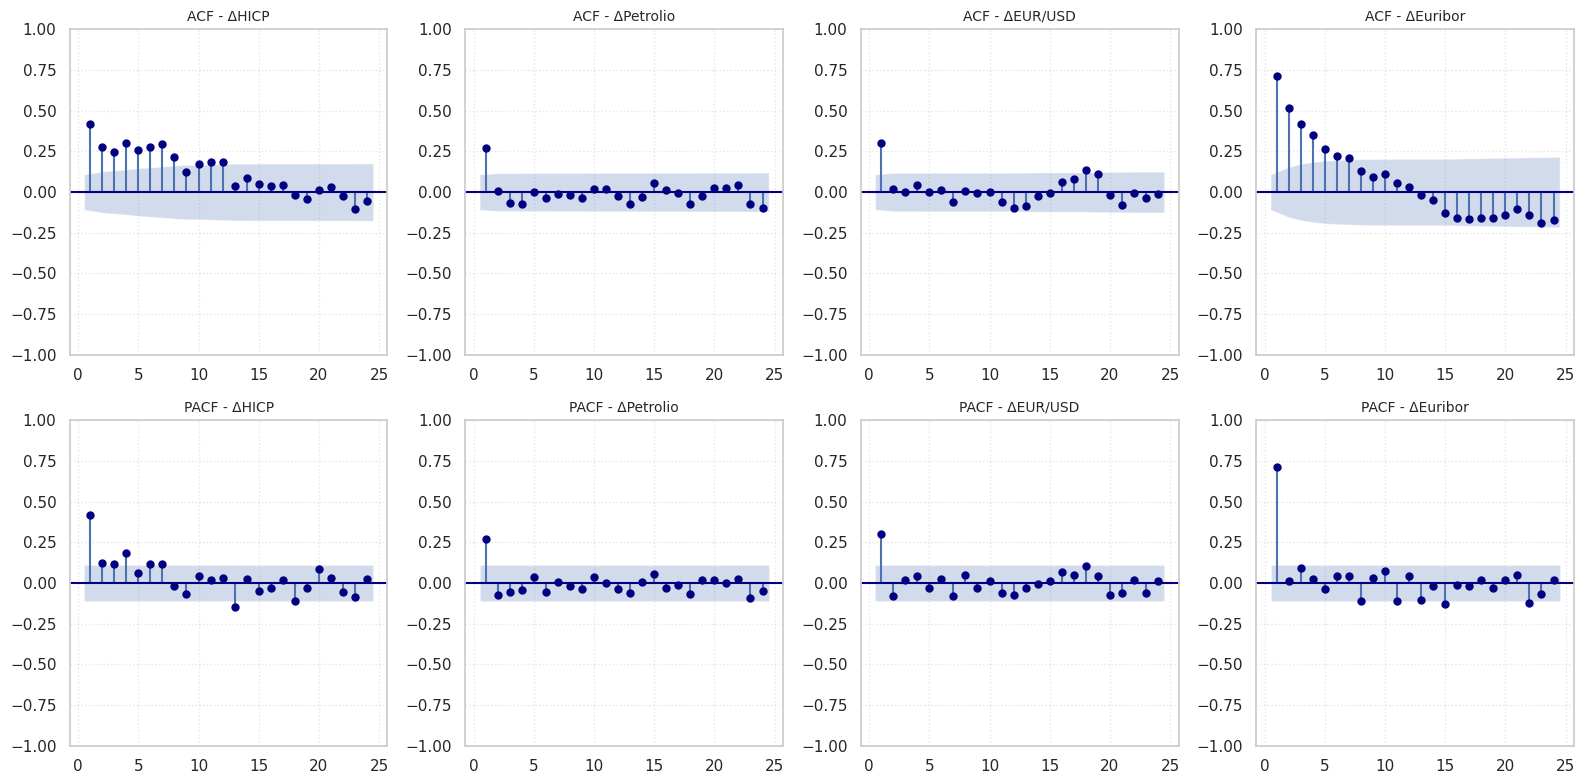

/tmp/ipykernel_1735/259903044.py:47: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/tmp/ipykernel_1735/259903044.py:47: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/tmp/ipykernel_1735/259903044.py:47: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/tmp/ipykernel_1735/259903044.py:47: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/tmp/ipykernel_1735/259903044.py:47: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller


          TEST FORMALI DI RADICE UNITARIA
Variabile Levels ADF (p-val) Levels KPSS (p-val) Diff ADF (p-val) Diff KPSS (p-val)
   l_hicp             0.9716              0.0100           0.0083            0.1000
    gscpi             0.0037              0.0100           0.0000            0.1000
    l_oil             0.0071              0.0100           0.0000            0.1000
     l_fx             0.3136              0.0497           0.0000            0.1000
  euribor             0.2736              0.0100           0.0000            0.1000

--- Selezione automatica del modello ARIMA per ciascuna variabile nelle differenze prime ---

Variabile: l_hicp 
                                SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  330
Model:               SARIMAX(2, 1, 2)   Log Likelihood                1559.850
Date:                Fri, 14 Aug 2026   AIC                          -3107.699
Time:                 

In [121]:
# A. Grafico di stazionarietà visiva (Livelli vs. Differenze Prime)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Analisi di Stazionarietà: Livelli (I riga) vs. Differenze Prime (II riga)", fontsize=14, fontweight="bold")
cols_to_plot = ['l_hicp', 'gscpi', 'l_oil', 'l_fx', 'euribor']
titles_levels = ["l_hicp (Livello)", "GSCPI (Livello)", "l_oil (Livello)", "l_fx (Livello)", "Euribor 3M (Livello)"]
titles_diffs = ["Δ l_hicp (Infl. Mensile)", "Δ GSCPI", "Δ l_oil", "Δ l_fx", "Δ Euribor 3M"]

for col_idx, col in enumerate(cols_to_plot):
    axes[0, col_idx].plot(df.index, df[col], color="navy", lw=1.2)
    axes[0, col_idx].set_title(titles_levels[col_idx], fontsize=11)
    axes[0, col_idx].grid(True, linestyle=":", alpha=0.5)

    axes[1, col_idx].plot(df.index, df[col].diff(), color="crimson", lw=1)
    axes[1, col_idx].axhline(0, color="black", linestyle="--", lw=0.8)
    axes[1, col_idx].set_title(titles_diffs[col_idx], fontsize=11)
    axes[1, col_idx].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig("stazionarieta_visiva.png", dpi=300)
plt.show()

# B. Analisi Correlazione ACF e PACF delle differenze prime (Griglia Unica)
custom_titles = {'l_hicp': 'HICP', 'gscpi': 'GSCPI', 'l_oil': 'Petrolio', 'l_fx': 'EUR/USD', 'euribor': 'Euribor'}
cols_to_plot_acf = ['l_hicp', 'l_oil', 'l_fx', 'euribor']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))

for idx, col in enumerate(cols_to_plot_acf):
    target_diff = df[col].diff().dropna()
    plot_acf(target_diff, ax=axes[0, idx], lags=24, zero=False, color="navy")
    axes[0, idx].set_title(f"ACF - Δ{custom_titles[col]}", fontsize=10)
    axes[0, idx].grid(True, linestyle=":", alpha=0.5)

    plot_pacf(target_diff, ax=axes[1, idx], lags=24, zero=False, color="navy")
    axes[1, idx].set_title(f"PACF - Δ{custom_titles[col]}", fontsize=10)
    axes[1, idx].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
if SAVE_IMAGES:
    plt.savefig("acf_pacf_griglia.png", dpi=300)
plt.show()

# C. Tabella riassuntiva dei Test di Radice Unitaria (ADF / KPSS)
def run_unit_root_tests(series, name):
    s = series.dropna()
    adf_p = adfuller(s)[1]
    kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
    return adf_p, kpss_p

root_results = []
for col in df.columns:
    lvl_adf, lvl_kpss = run_unit_root_tests(df[col], col)
    diff_adf, diff_kpss = run_unit_root_tests(df[col].diff(), f"D.{col}")
    root_results.append({
        'Variabile': col,
        'Levels ADF (p-val)': f"{lvl_adf:.4f}", 'Levels KPSS (p-val)': f"{lvl_kpss:.4f}",
        'Diff ADF (p-val)': f"{diff_adf:.4f}", 'Diff KPSS (p-val)': f"{diff_kpss:.4f}"
    })
print("\n" + "="*50 + "\n          TEST FORMALI DI RADICE UNITARIA\n" + "="*50)
print(pd.DataFrame(root_results).to_string(index=False))

# D. Stima e Confronto ARIMA per GSCPI (AR(1) vs I(1)) (Tabella 4.3)
print("\n--- Selezione automatica del modello ARIMA per ciascuna variabile nelle differenze prime ---")
for col in df.columns:
    a = auto_arima(df[col], seasonal=False)
    print(f"\nVariabile: {col} \n", a.summary())

print("\n--- Stima e Confronto ARIMA per GSCPI (AR(1) vs I(1)) ---")
gscpi_ar1_model = ARIMA(df['gscpi'], order=(1, 0, 0)).fit()
print(gscpi_ar1_model.summary())

gscpi_i1_model = ARIMA(df['gscpi'], order=(0, 1, 0)).fit()
print(gscpi_i1_model.summary())

# E. Test VIF (Multicollinearità)
X_vif = df[['gscpi', 'l_oil', 'l_fx', 'euribor']].dropna()
X_vif_const = sm.add_constant(X_vif)
vif_data = pd.DataFrame()
vif_data["Variabile"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i+1) for i in range(len(X_vif.columns))]
print("\n" + "="*50 + "\n      TEST VIF (VARIANCE INFLATION FACTOR)\n" + "="*50)
print(vif_data.to_string(index=False))

## 5. Pipeline UECM ed Equazioni di Supporto
In questa cella vengono caricate le funzioni essenziali per stimare l'UECM nativo di `statsmodels` con errori robusti HAC, calcolare i moltiplicatori di lungo periodo via Delta Method ed effettuare la corretta scomposizione dei residui di breve periodo esenti da bug di allineamento di libreria.

In [122]:
# ==============================================================================
#  FUNZIONI DI SUPPORTO PER PIPELINE UECM E DIAGNOSTICA
# ==============================================================================
def plot_residuals_diagnostics(resid, model_label):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"Diagnostica dei Residui UECM - {model_label}", fontsize=14, fontweight="bold")

    axes[0, 0].plot(resid.index, resid, color="navy", lw=1)
    axes[0, 0].axhline(0, color="red", linestyle="--")
    axes[0, 0].set_title("Residui di breve periodo")

    sm.qqplot(resid, line="45", ax=axes[0, 1], fit=True)
    axes[0, 1].set_title("Q-Q Plot (Normalità)")

    sm.graphics.tsa.plot_acf(resid, ax=axes[1, 0], lags=24, zero=False)
    axes[1, 0].set_title("Autocorrelazione Residui (ACF)")

    sigma = np.sqrt(np.mean(resid**2))
    T = len(resid)
    ols_cusum = np.cumsum(resid) / (sigma * np.sqrt(T))
    axes[1, 1].plot(resid.index, ols_cusum, color="blue", label="OLS-CUSUM")
    axes[1, 1].axhline(1.358, color="red", linestyle="--", label="95% Limit (1.358)")
    axes[1, 1].axhline(-1.358, color="red", linestyle="--")
    axes[1, 1].set_title("Stabilità dei Parametri (OLS-CUSUM)")
    axes[1, 1].legend(loc="upper left")

    plt.tight_layout()
    if SAVE_IMAGES:
      plt.savefig(f"diagnostica_{model_label.lower().replace(' ', '_')}.png", dpi=300)
    plt.show()

def execute_uecm_pipeline(df, endog_col, exog_cols, fixed_df=None, model_label="Baseline", causal=False):
    print(f"\n" + "="*80)
    print(f" AVVIO STIMA MODELLO: {model_label.upper()}")
    print("="*80)

    sel_res = ardl_select_order(
        endog=df[endog_col], maxlag=6, exog=df[exog_cols], maxorder=6,
        trend="c", fixed=fixed_df, ic="aic", causal=causal
    )
    p_endog = sel_res.model.ardl_order[0]
    dl_lags_dict = sel_res.model.dl_lags

    order_dict = {}
    for var in exog_cols:
        lags_included = dl_lags_dict.get(var, [])
        if len(lags_included) > 0:
            order_dict[var] = max(1, int(max(lags_included)))
        else:
            order_dict[var] = 1
            print(f"[NOTA]: La variabile '{var}' era stata esclusa dal selettore dei lag. Forzato lag=1 per vincolo UECM.")

    print(f"Struttura finale dei lag esogeni applicata all'UECM: {order_dict}\n")

    corrected_ardl = ARDL(
        endog=df[endog_col], lags=p_endog, exog=df[exog_cols],
        order=order_dict, trend="c", fixed=fixed_df, causal=causal
    )
    uecm = UECM.from_ardl(corrected_ardl)
    uecm_fit = uecm.fit(cov_type='HAC', cov_kwds={'maxlags': 4})
    print(uecm_fit.summary())

    print("\n--- COINTEGRATION BOUNDS TEST (PSS 2001) ---")
    try:
        bounds_res = uecm_fit.bounds_test(case=3)
        print(bounds_res)
    except Exception as e:
        print(f"Errore nel calcolo del Bounds Test: {e}")

    print("\n--- PASS-THROUGH DI LUNGO PERIODO (Delta Method) ---")
    params = uecm_fit.params
    cov_mat = uecm_fit.cov_params()
    pvals = uecm_fit.pvalues

    alpha_key = f"{endog_col}.L1"
    if alpha_key in params:
        alpha = params[alpha_key]
        alpha_p = pvals[alpha_key]
        print(f"Velocità di Aggiustamento (alpha): {alpha:.5f} (p-val: {alpha_p:.4f})")

        lr_results = []
        for var in exog_cols:
            lr_key = f"{var}.L1"
            if lr_key in params:
                beta = params[lr_key]
                lr_multiplier = - beta / alpha

                v_beta = cov_mat.loc[lr_key, lr_key]
                v_alpha = cov_mat.loc[alpha_key, alpha_key]
                cov_ba = cov_mat.loc[lr_key, alpha_key]

                var_lr = (1.0 / (alpha**2)) * v_beta + ((beta**2) / (alpha**4)) * v_alpha - (2.0 * beta / (alpha**3)) * cov_ba
                se_lr = np.sqrt(max(0.0, var_lr))
                z_stat = lr_multiplier / se_lr
                p_val = 2 * (1 - norm.cdf(abs(z_stat)))

                ci_lower = lr_multiplier - 1.96 * se_lr
                ci_upper = lr_multiplier + 1.96 * se_lr

                sr_impact, sr_p = np.nan, np.nan
                for lag in [0, 1]:
                    sr_key = f"D.{var}.L{lag}"
                    if sr_key in params:
                        sr_impact = params[sr_key]
                        sr_p = pvals[sr_key]
                        break

                lr_results.append({
                    'Variabile': var.upper(),
                    'Impatto SR (Brevissimo)': sr_impact,
                    'SR p-value': sr_p,
                    'Moltiplicatore LR': lr_multiplier,
                    'LR Std. Error': se_lr,
                    'z-stat': z_stat,
                    'LR p-value': p_val,
                    'IC [0.025]': ci_lower,
                    'IC [0.975]': ci_upper
                })
        df_lr = pd.DataFrame(lr_results)
        print(df_lr.to_string(index=False))
    else:
        print("Errore: Coefficiente della velocità di aggiustamento (alpha) non trovato.")
        df_lr = pd.DataFrame()

    fitted_dy = uecm_fit.fittedvalues
    endog_diff_series = df[endog_col].diff()
    actual_dy = endog_diff_series.loc[fitted_dy.index]
    correct_resid = actual_dy - fitted_dy

    print("\n--- TEST DIAGNOSTICI SUI RESIDUI ---")
    lm_stat, lm_p, _, _ = acorr_lm(correct_resid, nlags=12, ddof=len(params))
    print(f"Breusch-Godfrey LM Autocorrelation Test (lag=12): p-val = {lm_p:.4f}")

    try:
        arch_stat, arch_p, _, _ = het_arch(correct_resid, nlags=12)
        print(f"ARCH-LM Heteroskedasticity Test (lag=12): p-val = {arch_p:.4f}")
    except Exception as e:
         print(f"ARCH-LM non calcolabile: {e}")

    jb_stat, jb_p, skew, kurt = jarque_bera(correct_resid)
    print(f"Jarque-Bera Normality Test: p-val = {jb_p:.4f} (Skewness: {skew:.2f}, Kurtosis: {kurt:.2f})")

    try:
        _,  cusum_p, _ = breaks_cusumolsresid(correct_resid, ddof=len(params))
        print(f"OLS-CUSUM Structural Stability: p-val = {cusum_p:.4f}")
    except Exception as e:
        print(f"OLS-CUSUM p-value non calcolabile: {e}")

    plot_residuals_diagnostics(correct_resid, model_label)

    return uecm_fit, df_lr

## 6. Stima Sequenziale (Nested Models) e Modello COVID-Adjusted
In questa sezione vengono stimati sequenzialmente 4 modelli per verificare la robustezza dei moltiplicatori dinamici ed evitare l'omitted variable bias.

Viene poi confrontato il modello Baseline con il modello COVID-Adjusted (Tabella 4.7) per evidenziare il guadagno di fit e il riallineamento dell'emivita dello shock.

In [123]:
# A. Stima dei 4 Modelli Sequenziali (Generazione della Tabella Comparativa 4.6)

specs = [
    ['gscpi'],
    ['gscpi', 'l_oil'],
    ['gscpi', 'l_oil', 'l_fx'],
    ['gscpi', 'l_oil', 'l_fx', 'euribor']
]

results_comparison = {}

for idx, exog_subset in enumerate(specs):
    if idx == 0:
        col_name = "Modello 1 (Solo GSCPI)"
    elif idx == 1:
        col_name = "Modello 2 (+ Petrolio)"
    elif idx == 2:
        col_name = "Modello 3 (+ Cambio)"
    else:
        col_name = "Modello 4 (Completo)"

    sel_res = ardl_select_order(
        endog=df['l_hicp'], maxlag=6, exog=df[exog_subset], maxorder=6,
        trend="c", fixed=covid_dummy, ic="aic", causal=False
    )
    p_endog = sel_res.model.ardl_order[0]
    dl_lags_dict = sel_res.model.dl_lags

    order_dict = {}
    for var in exog_subset:
        lags_included = dl_lags_dict.get(var, [])
        order_dict[var] = max(1, int(max(lags_included))) if len(lags_included) > 0 else 1

    corrected_ardl = ARDL(
        endog=df['l_hicp'], lags=p_endog, exog=df[exog_subset],
        order=order_dict, trend="c", fixed=covid_dummy, causal=False
    )
    uecm = UECM.from_ardl(corrected_ardl)
    uecm_fit = uecm.fit(cov_type='HAC', cov_kwds={'maxlags': 4})

    metrics = {
        'Lag Structure (p, q...)': f"({p_endog}, " + ", ".join([str(order_dict[v]) for v in exog_subset]) + ")",
        'Log-Likelihood': round(uecm_fit.llf, 2),
        'AIC': round(uecm_fit.aic, 2),
        'BIC': round(uecm_fit.bic, 2),
    }

    try:
        bounds_res = uecm_fit.bounds_test(case=3)
        metrics['Bounds F-stat'] = round(bounds_res.stat, 3)
    except:
        metrics['Bounds F-stat'] = np.nan

    alpha = uecm_fit.params['l_hicp.L1']
    alpha_p = uecm_fit.pvalues['l_hicp.L1']
    metrics['Speed of Adj. (alpha)'] = f"{alpha:.5f} ({alpha_p:.4f})"

    params = uecm_fit.params
    cov_mat = uecm_fit.cov_params()

    for var in ['gscpi', 'l_oil', 'l_fx', 'euribor']:
        lr_key = f"{var}.L1"
        if lr_key in params:
            beta = params[lr_key]
            lr_mult = - beta / alpha

            v_beta = cov_mat.loc[lr_key, lr_key]
            v_alpha = cov_mat.loc['l_hicp.L1', 'l_hicp.L1']
            cov_ba = cov_mat.loc[lr_key, 'l_hicp.L1']
            var_lr = (1.0 / (alpha**2)) * v_beta + ((beta**2) / (alpha**4)) * v_alpha - (2.0 * beta / (alpha**3)) * cov_ba
            se_lr = np.sqrt(max(0.0, var_lr))
            z_stat = lr_mult / se_lr
            p_val = 2 * (1 - norm.cdf(abs(z_stat)))

            metrics[f'LR {var.upper()} (theta)'] = f"{lr_mult:.4f} ({p_val:.4f})"
        else:
            metrics[f'LR {var.upper()} (theta)'] = "N/A"

    results_comparison[col_name] = metrics

df_comparison = pd.DataFrame(results_comparison)
print("\n" + "="*100 + "\n                    TABELLA COMPARATIVA DELLE SPECIFICHE (Robustness Check)\n" + "="*100)
print(df_comparison.to_string())



                    TABELLA COMPARATIVA DELLE SPECIFICHE (Robustness Check)
                        Modello 1 (Solo GSCPI) Modello 2 (+ Petrolio) Modello 3 (+ Cambio) Modello 4 (Completo)
Lag Structure (p, q...)                 (2, 6)              (5, 6, 4)         (1, 6, 4, 1)      (1, 6, 4, 1, 1)
Log-Likelihood                         1560.62                 1631.9              1638.52              1639.14
AIC                                   -3097.23               -3223.81             -3241.05             -3238.28
BIC                                   -3051.87               -3148.19              -3173.0             -3162.67
Bounds F-stat                           17.294                  5.811               32.248               28.394
Speed of Adj. (alpha)        -0.00487 (0.0000)      -0.00584 (0.0002)    -0.00912 (0.0000)    -0.00864 (0.0002)
LR GSCPI (theta)               0.1535 (0.0006)        0.0946 (0.0035)      0.0817 (0.0001)      0.0877 (0.0215)
LR L_OIL (theta)           


 AVVIO STIMA MODELLO: BASELINE
Struttura finale dei lag esogeni applicata all'UECM: {'gscpi': 6, 'l_oil': 4, 'l_fx': 1}

                              UECM Model Results                              
Dep. Variable:               D.l_hicp   No. Observations:                  330
Model:               UECM(5, 6, 4, 1)   Log Likelihood                1631.201
Method:               Conditional MLE   S.D. of innovations              4.323
Date:                Fri, 14 Aug 2026   AIC                          -3220.402
Time:                        14:30:07   BIC                          -3141.007
Sample:                    07-31-1999   HQIC                         -3188.712
                         - 06-30-2026                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0059      0.003      2.185      0.030       0.001       0.011
l_hicp

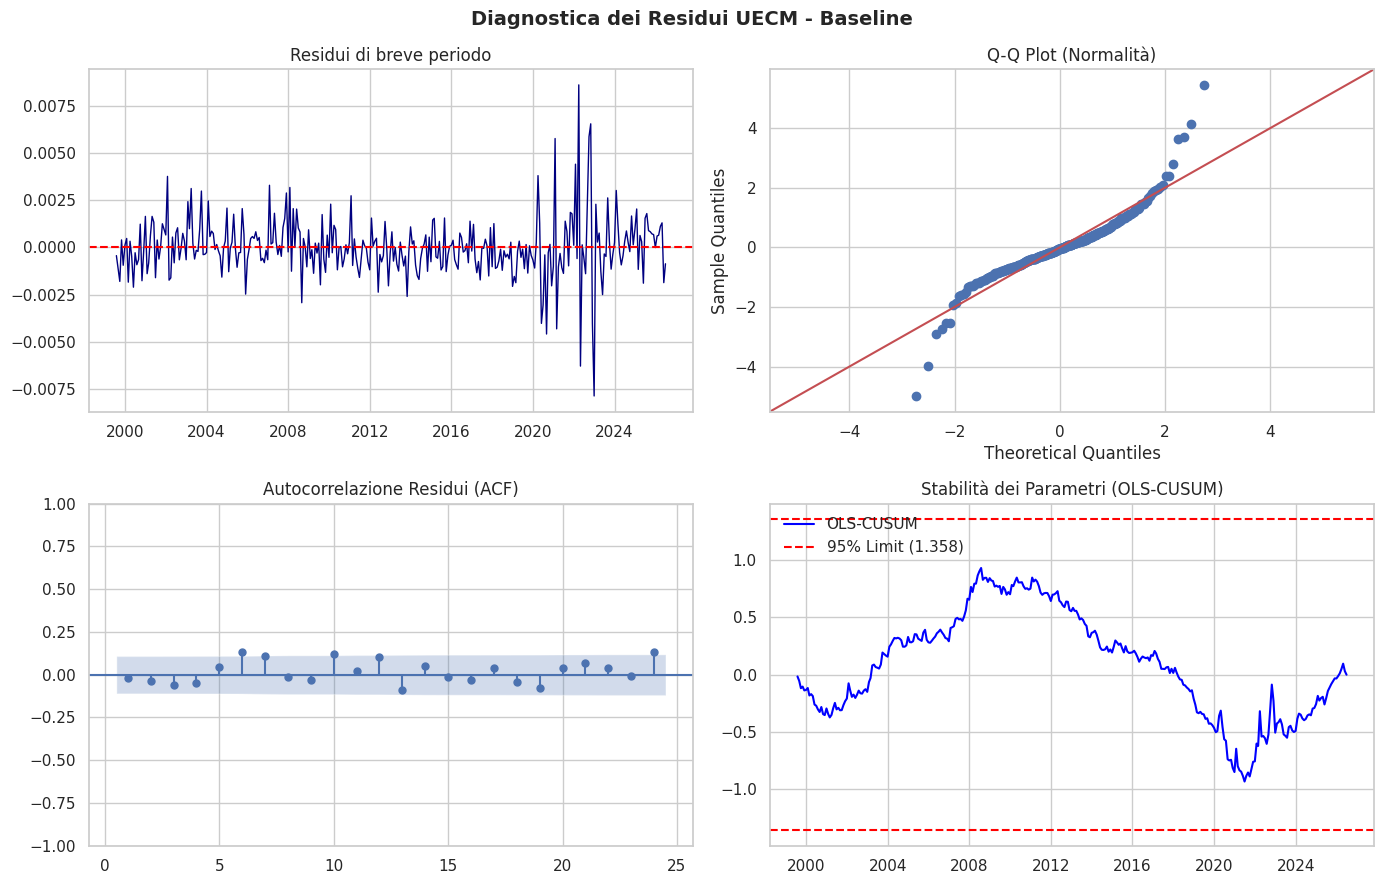


 AVVIO STIMA MODELLO: COVID ADJUSTED
Struttura finale dei lag esogeni applicata all'UECM: {'gscpi': 6, 'l_oil': 4, 'l_fx': 1}

                              UECM Model Results                              
Dep. Variable:               D.l_hicp   No. Observations:                  330
Model:               UECM(1, 6, 4, 1)   Log Likelihood                1638.525
Method:               Conditional MLE   S.D. of innovations              4.323
Date:                Fri, 14 Aug 2026   AIC                          -3241.049
Time:                        14:30:09   BIC                          -3172.996
Sample:                    07-31-1999   HQIC                         -3213.886
                         - 06-30-2026                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0318      0.005      5.954      0.000       0.021       0.042


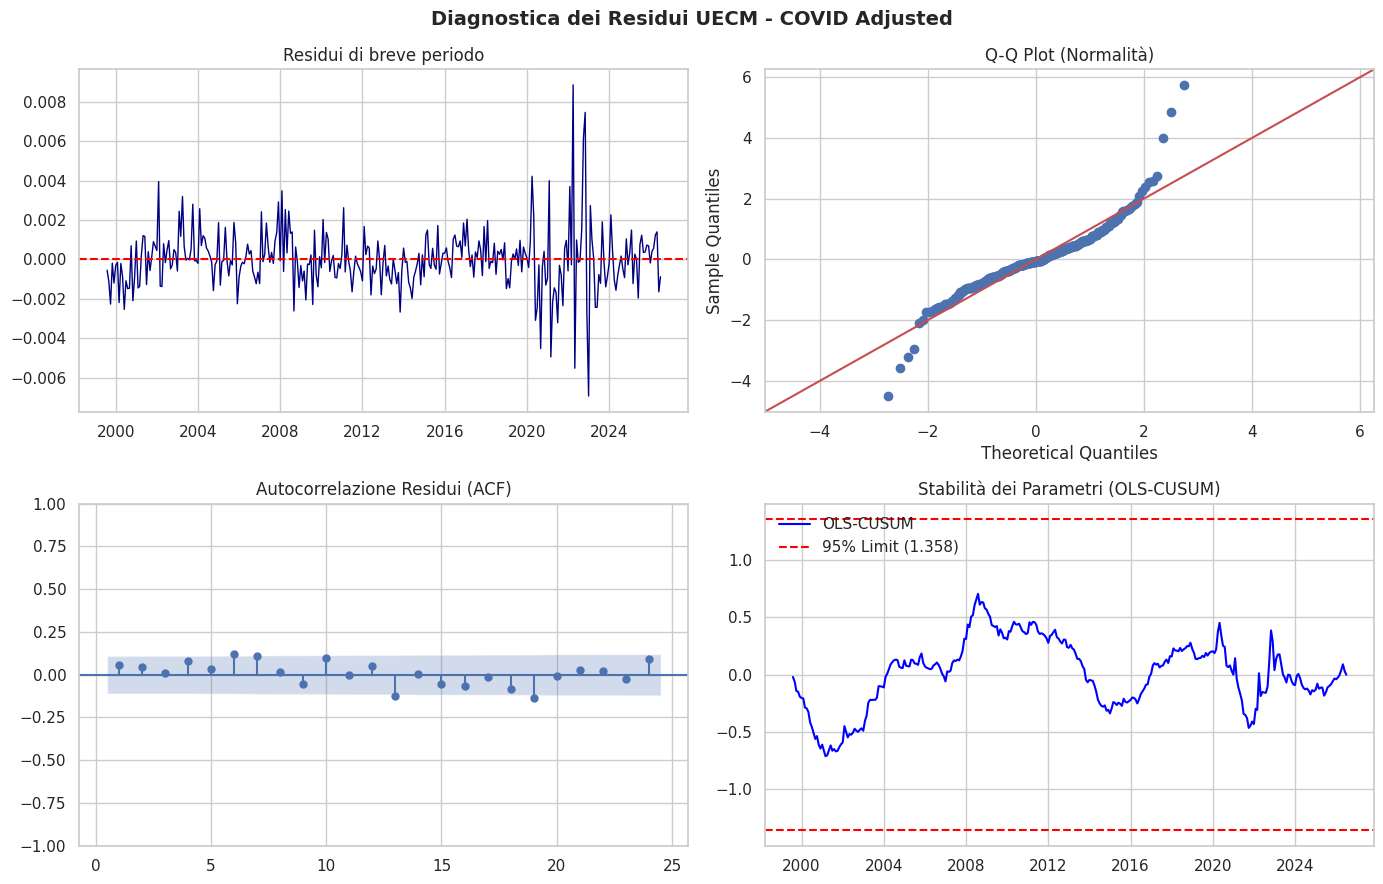


                 ANALISI DI PERSISTENZA DEL MODELLO DI TESI
Emivita (Half-life) in mesi: 75.62
Emivita (Half-life) in anni: 6.30


In [124]:
# B. Stima del Modello Baseline vs. COVID-Adjusted (M3) (Generazione della Tabella 4.7)
baseline_fit, baseline_lr = execute_uecm_pipeline(
    df=df, endog_col='l_hicp', exog_cols=['gscpi', 'l_oil', 'l_fx'],
    fixed_df=None, model_label="Baseline", causal=False
)

covid_fit, covid_lr = execute_uecm_pipeline(
    df=df, endog_col='l_hicp', exog_cols=['gscpi', 'l_oil', 'l_fx'],
    fixed_df=covid_dummy, model_label="COVID Adjusted", causal=False
)

# C. Calcolo dell'emivita (Half-Life) per il modello finale di tesi
alpha_val = covid_fit.params['l_hicp.L1']
half_life_months = np.log(0.5) / np.log(1 + alpha_val)
print("\n" + "="*50 + "\n                 ANALISI DI PERSISTENZA DEL MODELLO DI TESI\n" + "="*50)
print(f"Emivita (Half-life) in mesi: {half_life_months:.2f}")
print(f"Emivita (Half-life) in anni: {half_life_months / 12:.2f}")

## 7. Simulazioni Dinamiche e Riconciliazione con la Letteratura (Conclusioni)
Poiché l'equilibrio stimato dall'UECM si basa su variazioni permanenti, per simulare scenari reali e transitori (coerentemente con Finck & Tillmann, 2023) impostiamo uno shock di 1 deviazione standard del GSCPI che decade nel tempo secondo tre livelli di persistenza.  
Questa cella genera ed esporta i due grafici fondamentali inseriti nelle Conclusioni (Figura 5.1 e Figura 5.2)


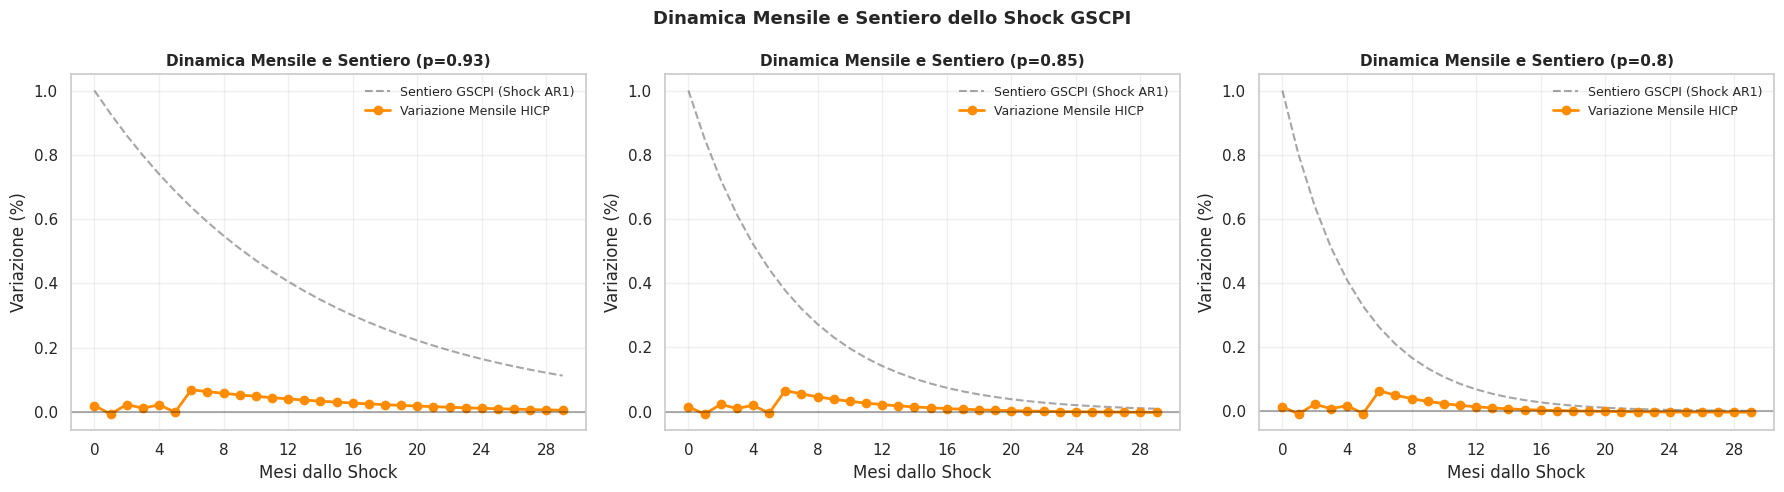

Risultato Chiave (rho=0.93): Il picco cumulato è di 0.7595% al mese 29.
Risultato Chiave (rho=0.85): Il picco cumulato è di 0.4195% al mese 23.
Risultato Chiave (rho=0.80): Il picco cumulato è di 0.3255% al mese 19.


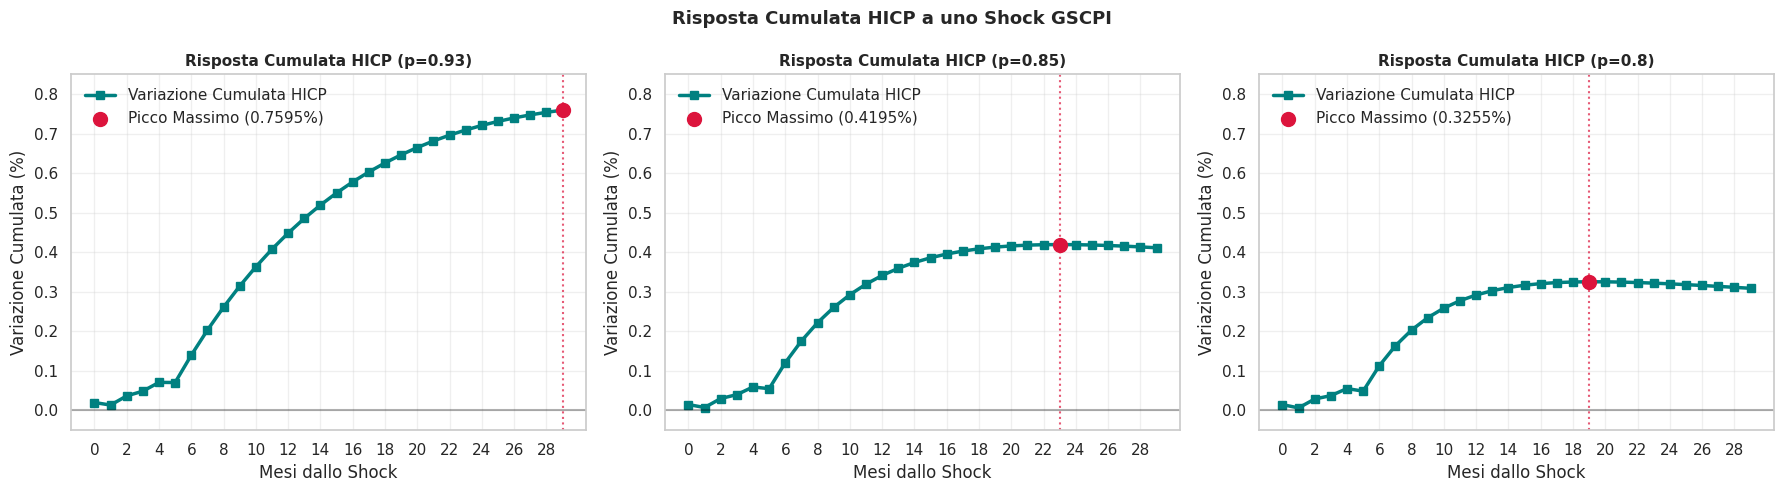

In [125]:
alpha = covid_fit.params['l_hicp.L1']
delta_gscpi = covid_fit.params['gscpi.L1']
ar1_par = gscpi_ar1_model.params['ar.L1']

# Coefficienti dinamici di breve periodo per D.gscpi (L0 a L5)
eta = [
    covid_fit.params.get('D.gscpi.L0', 0.0),
    covid_fit.params.get('D.gscpi.L1', 0.0),
    covid_fit.params.get('D.gscpi.L2', 0.0),
    covid_fit.params.get('D.gscpi.L3', 0.0),
    covid_fit.params.get('D.gscpi.L4', 0.0),
    covid_fit.params.get('D.gscpi.L5', 0.0)
]

def simulate_hicp_response(rho, steps=30):
    start_idx = 5
    total_steps = steps + start_idx + 5

    x = np.zeros(total_steps)
    dy = np.zeros(total_steps)
    y = np.zeros(total_steps)

    # Shock unitario transitorio che decade geometricamente (AR1)
    val = 1.0
    for i in range(start_idx, total_steps):
        x[i] = val
        val *= rho

    # Loop UECM
    for t in range(start_idx, steps + start_idx):
        sr_term = 0.0
        for k in range(len(eta)):
            idx_now = t - k
            dx_val = x[idx_now] - x[idx_now - 1]
            sr_term += eta[k] * dx_val

        dy[t] = alpha * y[t - 1] + delta_gscpi * x[t - 1] + sr_term
        y[t] = y[t - 1] + dy[t]

    y_response = y[start_idx:start_idx + steps] * 100
    dy_response = dy[start_idx:start_idx + steps] * 100
    gscpi_path = x[start_idx:start_idx + steps]

    return gscpi_path, y_response, dy_response

# A. Generazione e salvataggio dei Grafici delle Conclusioni (30 mesi)
horizon = 30
rho_list = [ar1_par, 0.85, 0.8]
rho_labels = [f"p={ar1_par:.2f}", "p=0.85", "p=0.8"]

# --- GRAFICO 1: Dinamica mensile del rientro dello shock (Figura 5.1) ---
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
fig.suptitle("Dinamica Mensile e Sentiero dello Shock GSCPI", fontsize=13, fontweight="bold")

for idx, rho in enumerate(rho_list):
    gscpi_path, _, dy_response = simulate_hicp_response(rho=rho, steps=horizon)
    ax = axes[idx]
    ax.plot(range(horizon), gscpi_path, color='gray', linestyle='--', alpha=0.7, label='Sentiero GSCPI (Shock AR1)')
    ax.plot(range(horizon), dy_response, color='darkorange', linewidth=2, marker='o', label='Variazione Mensile HICP')
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_title(f"Dinamica Mensile e Sentiero ({rho_labels[idx]})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Mesi dallo Shock")
    ax.set_ylabel("Variazione (%)")
    ax.set_xticks(range(0, horizon, 4))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
if SAVE_IMAGES:
  plt.savefig("dinamica_gscpi_concl.png", dpi=300)
plt.show()

# --- GRAFICO 2: Risposta Cumulata HICP (Figura 5.2) ---
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
fig.suptitle("Risposta Cumulata HICP a uno Shock GSCPI", fontsize=13, fontweight="bold")

for idx, rho in enumerate(rho_list):
    _, y_response, _ = simulate_hicp_response(rho=rho, steps=horizon)
    peak_idx = np.argmax(y_response)
    peak_val = y_response[peak_idx]

    ax = axes[idx]
    ax.plot(range(horizon), y_response, color='teal', linewidth=2.5, marker='s', label='Variazione Cumulata HICP')
    ax.scatter(peak_idx, peak_val, color='crimson', s=100, zorder=5, label=f'Picco Massimo ({peak_val:.4f}%)')
    ax.axvline(peak_idx, color='crimson', linestyle=':', alpha=0.7)
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)

    ax.set_title(f"Risposta Cumulata HICP ({rho_labels[idx]})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Mesi dallo Shock")
    ax.set_ylabel("Variazione Cumulata (%)")
    ax.set_xticks(range(0, horizon, 2))
    ax.set_ylim(-0.05, 0.85)
    ax.grid(True, alpha=0.3)
    ax.legend()

    print(f"Risultato Chiave (rho={rho:.2f}): Il picco cumulato è di {peak_val:.4f}% al mese {peak_idx}.")

plt.tight_layout()
if SAVE_IMAGES:
  plt.savefig("hicp_cumulata_concl.png", dpi=300)
plt.show()